# Feature Engineering & Model Optimization
## Titanic Survival Prediction

**AnalystLab Africa Data Science Internship**

**Objective:** Create meaningful new features, transform and select the most relevant variables, apply hyperparameter tuning with cross-validation, and evaluate model performance before and after optimization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
BLUE, ORANGE, GREEN, RED, PURPLE, TEAL = '#2563EB','#F97316','#16A34A','#DC2626','#7C3AED','#0891B2'

In [2]:
## Data Loading & Baseline Preprocessing

titanic = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_6_Project\Titanic-Dataset.csv")

dataset_info = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [titanic.shape[0], titanic.shape[1]]
})

missing_values = (
    titanic.isnull()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing Values"})
)

dataset_info
missing_values
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
dataset_info

,Metric,Value
0,Rows,891
1,Columns,12


In [4]:
missing_values

,Column,Missing Values
0,PassengerId,0
1,Survived,0
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,177
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,0


In [5]:
# Filling missing values 
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(
    titanic['Embarked'].mode()[0]
)

## Feature Engineering
### Title Extraction from Name

**What:** Extracting the social title (Mr, Mrs, Miss, Master, etc.) from each passenger's name string.

**Why:** Title encodes age, gender, and social status simultaneously'Master' identifies boys under 13, 'Mrs' identifies married women, 'Rare' groups military/nobility titles. This is more informative than age or sex alone.

In [6]:
# Extract passenger titles
titanic['Title'] = titanic['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

raw_titles = titanic['Title'].value_counts()

# Group rare titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

titanic['Title'] = titanic['Title'].replace(rare_titles, 'Rare')
titanic['Title'] = titanic['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

grouped_titles = titanic['Title'].value_counts()

title_comparison = pd.concat(
    [
        raw_titles.rename("Raw Count"),
        grouped_titles.rename("Grouped Count")
    ],
    axis=1
).fillna(0).astype(int)

title_comparison

,Raw Count,Grouped Count
Title,,
Mr,517,517
Miss,182,185
Mrs,125,126
Master,40,40
Dr,7,0
Rev,6,0
Major,2,0
Mlle,2,0
Col,2,0


### Family Size

**What:** `FamilySize = SibSp + Parch + 1` (including the passenger themselves).

**Why:** Captures the total travel group size. Small families (2-4) had higher survival rates than solo travellers or very large families — a non-linear relationship that raw SibSp/Parch miss individually.

In [7]:
# Creating FamilySize feature
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1

family_size_distribution = pd.DataFrame({
    "Family Size": titanic['FamilySize'].value_counts().sort_index().index,
    "Passenger Count": titanic['FamilySize'].value_counts().sort_index().values,
    "Percentage (%)": (
        titanic['FamilySize']
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
        .values
    )
})

family_size_distribution

,Family Size,Passenger Count,Percentage (%)
0,1,537,60.27
1,2,161,18.07
2,3,102,11.45
3,4,29,3.25
4,5,15,1.68
5,6,22,2.47
6,7,12,1.35
7,8,6,0.67
8,11,7,0.79


### IsAlone

**What:** Binary flag  -1 if passenger travelled without family, 0 otherwise.

**Why:** Solo travellers had only 30.4% survival vs 50.6% for those with family. A clean binary capture of the biggest split in the family-size dimension.

In [8]:
# Creating IsAlone feature
titanic['IsAlone'] = (titanic['FamilySize'] == 1).astype(int)

isalone_summary = pd.DataFrame({
    "Category": ["Not Alone", "Alone"],
    "Passenger Count": [
        (titanic['IsAlone'] == 0).sum(),
        (titanic['IsAlone'] == 1).sum()
    ],
    "Percentage (%)": [
        round((titanic['IsAlone'] == 0).mean() * 100, 2),
        round((titanic['IsAlone'] == 1).mean() * 100, 2)
    ]
})

isalone_summary

,Category,Passenger Count,Percentage (%)
0,Not Alone,354,39.73
1,Alone,537,60.27


### Family Size Group

**What:** Categorical grouping  Alone (size=1), Small (2-4), Large (5+).

**Why:** Captures the non-linear relationship between family size and survival: small families survive best, large families struggle to coordinate evacuation.

In [9]:
# Creating FamilySizeGroup feature
def family_group(s):
    return 'Alone' if s == 1 else ('Small' if s <= 4 else 'Large')

titanic['FamilySizeGroup'] = titanic['FamilySize'].apply(family_group)

family_group_summary = (
    titanic.groupby('FamilySizeGroup')
    .agg(
        Passengers=('Survived', 'count'),
        Survival_Rate=('Survived', lambda x: round(x.mean() * 100, 1))
    )
    .rename(columns={'Survival_Rate': 'Survival Rate (%)'})
)

family_group_summary

,Passengers,Survival Rate (%)
FamilySizeGroup,,
Alone,537,30.4
Large,62,16.1
Small,292,57.9


### Age Bands

**What:** Bin Age into meaningful life-stage groups: Child (0-12), Teen (13-18), Young Adult (19-35), Adult (36-60), Senior (60+).

**Why:** The evacuation protocol extended to children specifically Age's effect on survival is not linear across the full range, but categorical bands capture the key breakpoints (children prioritized, elderly less mobile).

In [10]:
# Creating age groups
titanic['AgeBand'] = pd.cut(
    titanic['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

# Displaying survival summary by age group
ageband_summary = (
    titanic.groupby('AgeBand', observed=True)
    .agg(
        Passengers=('Survived', 'count'),
        Survival_Rate=('Survived', lambda x: round(x.mean() * 100, 1))
    )
    .rename(columns={'Survival_Rate': 'Survival Rate (%)'})
)

ageband_summary

,Passengers,Survival Rate (%)
AgeBand,,
Child,69,58.0
Teen,70,42.9
Young Adult,535,35.3
Adult,195,40.0
Senior,22,22.7


### Fare Per Person

**What:** Divide Fare by the number of passengers sharing the same ticket number.

**Why:** Groups of passengers often split one ticket, making the raw Fare artificially inflated for multiple people. Fare Per Person more accurately represents individual socioeconomic level.

In [11]:
# Filling missing Fare values
titanic['Fare'] = titanic['Fare'].fillna(titanic['Fare'].median())

# Creating new features
ticket_counts = titanic['Ticket'].value_counts()
titanic['TicketCount'] = titanic['Ticket'].map(ticket_counts)
titanic['FarePerPerson'] = titanic['Fare'] / titanic['TicketCount']

# Customizing summary statistics
fare_per_person_summary = pd.DataFrame({
    "Statistic": ["Count", "Mean", "Std Dev", "Minimum", "25%", "Median", "75%", "Maximum"],
    "Value": [
        titanic['FarePerPerson'].count(),
        titanic['FarePerPerson'].mean(),
        titanic['FarePerPerson'].std(),
        titanic['FarePerPerson'].min(),
        titanic['FarePerPerson'].quantile(0.25),
        titanic['FarePerPerson'].median(),
        titanic['FarePerPerson'].quantile(0.75),
        titanic['FarePerPerson'].max()
    ]
}).round(2)

fare_per_person_summary

,Statistic,Value
0,Count,891.00
1,Mean,17.79
2,Std Dev,21.22
3,Minimum,0.00
4,25%,7.76
5,Median,8.85
6,75%,24.29
7,Maximum,221.78


### Fare Band

**What:** Quartile-based binning of Fare into Low, Mid, High, VeryHigh.

**Why:** Captures the socioeconomic tier associated with fare level a categorical version that handles Fare's extreme right skew better than the raw value in some models.

In [12]:
# Create fare bands (quartiles)
titanic['FareBand'] = pd.qcut(
    titanic['Fare'],
    q=4,
    labels=['Low', 'Mid', 'High', 'Very High']
)

# Summary of survival by fare band
fareband_summary = (
    titanic.groupby('FareBand', observed=True)
    .agg(
        Passengers=('Survived', 'count'),
        Survival_Rate=('Survived', lambda x: round(x.mean() * 100, 1))
    )
    .rename(columns={'Survival_Rate': 'Survival Rate (%)'})
)

fareband_summary

,Passengers,Survival Rate (%)
FareBand,,
Low,223,19.7
Mid,224,30.4
High,222,45.5
Very High,222,58.1


### Cabin Known

**What:** Binary flag  1 if cabin information is available, 0 if missing.

**Why:** 77% of cabin data is missing, but whether a cabin is *recorded* is itself informative passengers with known cabins tend to be 1st class or wealthier, with a survival rate of 66.7% vs 30% for those without cabin records.

In [13]:
# Creating a binary feature indicating whether cabin information is available
titanic['CabinKnown'] = titanic['Cabin'].notna().astype(int)

# Displaying survival summary by cabin information
cabin_summary = (
    titanic.groupby('CabinKnown')
    .agg(
        Passengers=('Survived', 'count'),
        Survival_Rate=('Survived', lambda x: round(x.mean() * 100, 1))
    )
    .rename(index={0: 'Cabin Unknown', 1: 'Cabin Known'})
    .rename(columns={'Survival_Rate': 'Survival Rate (%)'})
)

cabin_summary

,Passengers,Survival Rate (%)
CabinKnown,,
Cabin Unknown,687,30.0
Cabin Known,204,66.7


### Sex × Pclass Interaction

**What:** `SexPclass = Sex_encoded × Pclass`  a multiplicative interaction term combining sex and class.

**Why:** The effect of sex on survival is not uniform across classes a 3rd class female survived at 50% while a 1st class female survived at 97%. This interaction feature captures that compounding effect explicitly.

In [14]:
# Survival rate (%) by Sex and Passenger Class
titanic['SexPclass'] = titanic['Sex'].map({'male':1,'female':0}) * titanic['Pclass']

# Survival summary by Sex and Passenger Class
sex_pclass_summary = (
    titanic.groupby(['Sex', 'Pclass'])
    .agg(
        Passengers=('Survived', 'count'),
        Survivors=('Survived', 'sum'),
        Survival_Rate=('Survived', lambda x: round(x.mean() * 100, 1))
    )
    .rename(columns={'Survival_Rate': 'Survival Rate (%)'})
)

sex_pclass_summary

Passengers  Survivors  Survival Rate (%)
Sex    Pclass                                          
female 1               94         91               96.8
       2               76         70               92.1
       3              144         72               50.0
male   1              122         45               36.9
       2              108         17               15.7
       3              347         47               13.5

## Feature Transformation

In [15]:
# Encoding all categorical features 
le = LabelEncoder()

# Filling missing Embarked values before encoding
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

# Encoding categorical features
for col in ['Sex', 'Embarked', 'Title', 'AgeBand', 'FareBand', 'FamilySizeGroup']:
    titanic[col + '_enc'] = le.fit_transform(titanic[col].astype(str))

# Displaying encoding summary
encoding_summary = pd.DataFrame({
    "Feature": [
        "Sex",
        "Embarked",
        "Title",
        "AgeBand",
        "FareBand",
        "FamilySizeGroup"
    ],
    "Encoded Column": [
        "Sex_enc",
        "Embarked_enc",
        "Title_enc",
        "AgeBand_enc",
        "FareBand_enc",
        "FamilySizeGroup_enc"
    ]
})

encoding_summary

,Feature,Encoded Column
0,Sex,Sex_enc
1,Embarked,Embarked_enc
2,Title,Title_enc
3,AgeBand,AgeBand_enc
4,FareBand,FareBand_enc
5,FamilySizeGroup,FamilySizeGroup_enc


In [16]:
# Displaying the encoding mappings
for col in ['Sex', 'Embarked', 'Title', 'AgeBand', 'FareBand', 'FamilySizeGroup']:
    mapping = (
        titanic[[col, col + '_enc']]
        .drop_duplicates()
        .sort_values(col + '_enc')
        .reset_index(drop=True)
    )

    display(mapping)

,Sex,Sex_enc
0,female,0
1,male,1


,Embarked,Embarked_enc
0,C,0
1,Q,1
2,S,2


,Title,Title_enc
0,Master,0
1,Miss,1
2,Mr,2
3,Mrs,3
4,Rare,4


,AgeBand,AgeBand_enc
0,Adult,0
1,Child,1
2,Senior,2
3,Teen,3
4,Young Adult,4


,FareBand,FareBand_enc
0,High,0
1,Low,1
2,Mid,2
3,Very High,3


,FamilySizeGroup,FamilySizeGroup_enc
0,Alone,0
1,Large,1
2,Small,2


In [17]:
# Standardization
# Applied to all features for Logistic Regression compatibility and fair coefficient comparison.
# Tree-based models (RF, GB) are scale-invariant, but we scale all features consistently
# since they share the same feature matrix.

all_features = [
    'Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare',
    'FamilySize', 'IsAlone', 'FarePerPerson', 'CabinKnown',
    'SexPclass', 'Title_enc', 'AgeBand_enc',
    'FareBand_enc', 'FamilySizeGroup_enc', 'Embarked_enc'
]
print(all_features)

['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'CabinKnown', 'SexPclass', 'Title_enc', 'AgeBand_enc', 'FareBand_enc', 'FamilySizeGroup_enc', 'Embarked_enc']


In [18]:
# Verify Age has no missing values
titanic['Age'].isnull().sum()

np.int64(0)

In [19]:

# Creating feature matrix
X_all = titanic[all_features]
y = titanic['Survived']

In [20]:
X_all.head()

,Pclass,Sex_enc,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,CabinKnown,SexPclass,Title_enc,AgeBand_enc,FareBand_enc,FamilySizeGroup_enc,Embarked_enc
0,3,1,22.0,1,0,7.2500,2,0,7.2500,0,3,2,4,1,2,2
1,1,0,38.0,1,0,71.2833,2,0,71.2833,1,0,3,0,3,2,0
2,3,0,26.0,0,0,7.9250,1,1,7.9250,0,0,1,4,2,0,2
3,1,0,35.0,1,0,53.1000,2,0,26.5500,1,0,3,4,3,2,2
4,3,1,35.0,0,0,8.0500,1,1,8.0500,0,3,2,4,2,0,2


In [21]:
#verifying for no missing values
X_all[['Age']].isnull().sum()

Age    0
dtype: int64

In [22]:
# Standardizing features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_all),
    columns=all_features
)

X_scaled.isnull().sum().sort_values(ascending=False)


Pclass                 0
Sex_enc                0
Age                    0
SibSp                  0
Parch                  0
Fare                   0
FamilySize             0
IsAlone                0
FarePerPerson          0
CabinKnown             0
SexPclass              0
Title_enc              0
AgeBand_enc            0
FareBand_enc           0
FamilySizeGroup_enc    0
Embarked_enc           0
dtype: int64

In [23]:
# Dataset summary
scaled_summary = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [X_scaled.shape[0], X_scaled.shape[1]]
})

scaled_summary
X_scaled.head()

,Pclass,Sex_enc,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,CabinKnown,SexPclass,Title_enc,AgeBand_enc,FareBand_enc,FamilySizeGroup_enc,Embarked_enc
0,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,0.059160,-1.231645,-0.496976,-0.544925,1.103701,0.132454,0.732082,-0.448320,1.379008,0.585954
1,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,0.059160,-1.231645,2.522573,1.835115,-1.176201,1.401453,-1.637708,1.342949,1.379008,-1.942303
2,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,-0.560975,0.811922,-0.465145,-0.544925,-1.176201,-1.136545,0.732082,0.447315,-0.784190,0.585954
3,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,0.059160,-1.231645,0.413134,1.835115,-1.176201,1.401453,0.732082,1.342949,1.379008,0.585954
4,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,-0.560975,0.811922,-0.459251,-0.544925,1.103701,0.132454,0.732082,0.447315,-0.784190,0.585954


## Feature Selection

Three methods applied: Correlation Analysis, RF Feature Importance, and RFE.

In [24]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Age'].isnull().sum()

np.int64(0)

In [25]:
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

split_summary = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Rows": [X_train_all.shape[0], X_test_all.shape[0]],
    "Columns": [X_train_all.shape[1], X_test_all.shape[1]],
    "Percentage": ["80%", "20%"]
})

split_summary

,Dataset,Rows,Columns,Percentage
0,Training Set,712,16,80%
1,Testing Set,179,16,20%


### Correlation Analysis

In [26]:
corr_target = (
    X_scaled.corrwith(y)
    .abs()
    .sort_values(ascending=False)
    .to_frame(name='Absolute Correlation')
)

corr_target

,Absolute Correlation
Sex_enc,0.543351
SexPclass,0.542493
Pclass,0.338481
CabinKnown,0.316912
Fare,0.257307
FarePerPerson,0.254824
FamilySizeGroup_enc,0.249714
IsAlone,0.203367
Embarked_enc,0.167675
FareBand_enc,0.111219


In [27]:
# High correlation features
high_corr = corr_target[corr_target['Absolute Correlation'] > 0.30]

# Moderate correlation features
moderate_corr = corr_target[
    (corr_target['Absolute Correlation'] > 0.15) &
    (corr_target['Absolute Correlation'] <= 0.30)
]

# Low correlation features
low_corr = corr_target[corr_target['Absolute Correlation'] <= 0.15]

high_corr
moderate_corr
low_corr

,Absolute Correlation
FareBand_enc,0.111219
Parch,0.081629
Title_enc,0.071174
AgeBand_enc,0.067534
Age,0.064910
SibSp,0.035322
FamilySize,0.016639


In [28]:
# Correlation with the target variable
corr_target = (
    X_scaled.corrwith(y)
    .abs()
    .sort_values(ascending=False)
    .to_frame(name='Absolute Correlation')
)

# Categorizing feature importance
corr_target['Importance'] = pd.cut(
    corr_target['Absolute Correlation'],
    bins=[-1, 0.15, 0.30, 1],
    labels=['Low', 'Moderate', 'High']
)

corr_target

,Absolute Correlation,Importance
Sex_enc,0.543351,High
SexPclass,0.542493,High
Pclass,0.338481,High
CabinKnown,0.316912,High
Fare,0.257307,Moderate
FarePerPerson,0.254824,Moderate
FamilySizeGroup_enc,0.249714,Moderate
IsAlone,0.203367,Moderate
Embarked_enc,0.167675,Moderate
FareBand_enc,0.111219,Low


### Random Forest Feature Importance

In [29]:
# Training Random Forest for feature selection
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X_train_all, y_train)

# Feature importance summary
feature_importance = (
    pd.DataFrame({
        "Feature": all_features,
        "Importance": rf_sel.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.index += 1
feature_importance.index.name = "Rank"

feature_importance["Importance"] = feature_importance["Importance"].round(4)

feature_importance

,Feature,Importance
Rank,,
1,Age,0.1543
2,FarePerPerson,0.1359
3,Fare,0.1311
4,SexPclass,0.1283
5,Sex_enc,0.1256
6,Title_enc,0.0657
7,CabinKnown,0.0416
8,FamilySize,0.0372
9,Pclass,0.0369


### Recursive Feature Elimination (RFE)

In [30]:
X_train_all.isnull().sum().loc[lambda x: x > 0].to_frame(name="Missing Values")

,Missing Values


In [31]:
# Recursive Feature Elimination (RFE)

lr_rfe = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(
    estimator=lr_rfe,
    n_features_to_select=10
)

rfe.fit(X_train_all, y_train)

# Selected features
rfe_selected = pd.DataFrame({
    "Selected Feature": [
        feature for feature, selected in zip(all_features, rfe.support_) if selected
    ]
})

rfe_selected.index += 1
rfe_selected.index.name = "Rank"

rfe_selected

,Selected Feature
Rank,
1,Pclass
2,Sex_enc
3,Age
4,Fare
5,IsAlone
6,FarePerPerson
7,CabinKnown
8,SexPclass
9,FamilySizeGroup_enc


In [32]:
X_train_all.isnull().sum().sort_values(ascending=False)

Pclass                 0
Sex_enc                0
Age                    0
SibSp                  0
Parch                  0
Fare                   0
FamilySize             0
IsAlone                0
FarePerPerson          0
CabinKnown             0
SexPclass              0
Title_enc              0
AgeBand_enc            0
FareBand_enc           0
FamilySizeGroup_enc    0
Embarked_enc           0
dtype: int64

In [33]:
# Recursive Feature Elimination (RFE)

lr_rfe = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(
    estimator=lr_rfe,
    n_features_to_select=10
)

rfe.fit(X_train_all, y_train)

# Create a summary table
rfe_summary = pd.DataFrame({
    "Feature": all_features,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
}).sort_values(by=["Selected", "Ranking"], ascending=[False, True])

rfe_summary.index += 1
rfe_summary.index.name = "Rank"

rfe_summary

,Feature,Selected,Ranking
Rank,,,
1,Pclass,True,1
2,Sex_enc,True,1
3,Age,True,1
6,Fare,True,1
8,IsAlone,True,1
9,FarePerPerson,True,1
10,CabinKnown,True,1
11,SexPclass,True,1
15,FamilySizeGroup_enc,True,1


In [34]:
# Selected features only

rfe_selected = pd.DataFrame({
    "Selected Features": [
        feature
        for feature, selected in zip(all_features, rfe.support_)
        if selected
    ]
})

rfe_selected.index += 1
rfe_selected.index.name = "Rank"

rfe_selected

,Selected Features
Rank,
1,Pclass
2,Sex_enc
3,Age
4,Fare
5,IsAlone
6,FarePerPerson
7,CabinKnown
8,SexPclass
9,FamilySizeGroup_enc


### Final Feature Set

Cross-referencing all three selection methods, the final 10 features selected are those appearing consistently across correlation analysis, RF importance, and RFE:

In [35]:
type(corr_target)

pandas.DataFrame

In [36]:
corr_target.head()

,Absolute Correlation,Importance
Sex_enc,0.543351,High
SexPclass,0.542493,High
Pclass,0.338481,High
CabinKnown,0.316912,High
Fare,0.257307,Moderate


In [37]:
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X_train_all, y_train)

fi = pd.Series(
    rf_sel.feature_importances_,
    index=all_features
).sort_values(ascending=False)

fi

Age                    0.154292
FarePerPerson          0.135921
Fare                   0.131064
SexPclass              0.128299
Sex_enc                0.125642
Title_enc              0.065684
CabinKnown             0.041640
FamilySize             0.037167
Pclass                 0.036890
AgeBand_enc            0.029281
FareBand_enc           0.028010
SibSp                  0.022402
Embarked_enc           0.022229
FamilySizeGroup_enc    0.018851
Parch                  0.016695
IsAlone                0.005931
dtype: float64

In [38]:
final_features = [
    'Sex_enc', 'SexPclass', 'Title_enc', 'Pclass',
    'FarePerPerson', 'Fare', 'CabinKnown',
    'AgeBand_enc', 'FamilySize', 'IsAlone'
]

# Summary table
feature_summary = pd.DataFrame({
    "Feature": final_features,
    "Absolute Correlation": [corr_target.loc[f] for f in final_features],
    "RF Importance": [fi.loc[f] for f in final_features]
})

feature_summary

,Feature,Absolute Correlation,RF Importance
0,Sex_enc,Absolute Correlation 0.543351 Importance ...,0.125642
1,SexPclass,Absolute Correlation 0.542493 Importance ...,0.128299
2,Title_enc,Absolute Correlation 0.071174 Importance ...,0.065684
3,Pclass,Absolute Correlation 0.338481 Importance ...,0.036890
4,FarePerPerson,Absolute Correlation 0.254824 Importance ...,0.135921
5,Fare,Absolute Correlation 0.257307 Importance ...,0.131064
6,CabinKnown,Absolute Correlation 0.316912 Importance ...,0.041640
7,AgeBand_enc,Absolute Correlation 0.067534 Importance ...,0.029281
8,FamilySize,Absolute Correlation 0.016639 Importance ...,0.037167
9,IsAlone,Absolute Correlation 0.203367 Importance ...,0.005931


## Baseline Model

In [39]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=True):
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds),
        "Recall": recall_score(y_te, preds),
        "F1 Score": f1_score(y_te, preds),
        "ROC AUC": roc_auc_score(y_te, proba)
    }

    if cv:
        cv_scores = cross_val_score(
            model,
            X_tr,
            y_tr,
            cv=StratifiedKFold(5),
            scoring="accuracy"
        )

        results["CV Mean"] = cv_scores.mean()
        results["CV Std"] = cv_scores.std()

    return pd.DataFrame([results])
lr_results = evaluate_model(
    "LR Baseline (all features)",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_all,
    y_train,
    X_test_all,
    y_test
)

lr_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Mean,CV Std
0,LR Baseline (all features),0.810056,0.818182,0.652174,0.725806,0.862978,0.824515,0.027913


In [40]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=True):
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:,1]

    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds)
    rec = recall_score(y_te, preds)
    f1 = f1_score(y_te, preds)
    roc = roc_auc_score(y_te, proba)

    if cv:
        cv_scores = cross_val_score(
            model,
            X_tr,
            y_tr,
            cv=StratifiedKFold(5),
            scoring="accuracy"
        )

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": roc,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std()
    }
results = {}

results['LR Baseline (all features)'] = evaluate_model(
    "LR Baseline (all features)",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_all,
    y_train,
    X_test_all,
    y_test
)
results_table = pd.DataFrame.from_dict(results, orient='index')

results_table = results_table.round(4)

results_table

,Accuracy,Precision,Recall,F1,AUC,CV Mean,CV Std
LR Baseline (all features),0.8101,0.8182,0.6522,0.7258,0.863,0.8245,0.0279


## Advanced Models (Before Tuning)

In [41]:
X_train_sel = X_train_all[final_features]
X_test_sel = X_test_all[final_features]

In [42]:
type(X_train_sel)

pandas.DataFrame

In [43]:
results['RF (before tuning)'] = evaluate_model(
    'RF (before tuning)',
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_sel, y_train, X_test_sel, y_test
)

results['GB (before tuning)'] = evaluate_model(
    "GB (before tuning)",
    GradientBoostingClassifier(random_state=42),
    X_train_sel, y_train, X_test_sel, y_test
)
results_table = pd.DataFrame.from_dict(results, orient='index')

results_table = (
    results_table
    .round(4)
    .sort_values(by="Accuracy", ascending=False)
)

results_table

,Accuracy,Precision,Recall,F1,AUC,CV Mean,CV Std
LR Baseline (all features),0.8101,0.8182,0.6522,0.7258,0.8630,0.8245,0.0279
GB (before tuning),0.7989,0.7463,0.7246,0.7353,0.8540,0.8399,0.0268
RF (before tuning),0.7765,0.7302,0.6667,0.6970,0.8277,0.8175,0.0252


## Hyperparameter Tuning

### Random Forest GridSearchCV

In [44]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train_sel, y_train)

# Best parameters table
best_rf_params = pd.DataFrame([grid_rf.best_params_])
best_rf_params.index = ['Best Random Forest']

best_rf_params

,max_depth,max_features,min_samples_split,n_estimators
Best Random Forest,5,sqrt,5,300


In [45]:
# Displaying the best cross validation AUC
pd.DataFrame({
    'Best CV AUC': [round(grid_rf.best_score_, 4)]
}, index=['Random Forest'])

#Evaluating the Tuned model
results['RF (tuned)'] = evaluate_model(
    'RF (tuned)',
    grid_rf.best_estimator_,
    X_train_sel,
    y_train,
    X_test_sel,
    y_test,
    cv=True
)
results_table = (
    pd.DataFrame.from_dict(results, orient='index')
    .round(4)
    .sort_values('Accuracy', ascending=False)
)

results_table

,Accuracy,Precision,Recall,F1,AUC,CV Mean,CV Std
RF (tuned),0.8156,0.7727,0.7391,0.7556,0.8529,0.8133,0.0310
LR Baseline (all features),0.8101,0.8182,0.6522,0.7258,0.8630,0.8245,0.0279
GB (before tuning),0.7989,0.7463,0.7246,0.7353,0.8540,0.8399,0.0268
RF (before tuning),0.7765,0.7302,0.6667,0.6970,0.8277,0.8175,0.0252


### Gradient Boosting RandomizedSearchCV

In [46]:
param_dist_gb = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

rand_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=30,
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rand_gb.fit(X_train_sel, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 150, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [47]:
# Displaying the best parameters
best_gb_params = pd.DataFrame([rand_gb.best_params_])
best_gb_params.index = ['Best Gradient Boosting']

best_gb_params

,subsample,n_estimators,min_samples_split,max_depth,learning_rate
Best Gradient Boosting,0.7,250,5,2,0.15


In [48]:
# Displaing the Best Cross-Validation AUC
pd.DataFrame({
    'Best CV AUC': [round(rand_gb.best_score_, 4)]
}, index=['Gradient Boosting'])

,Best CV AUC
Gradient Boosting,0.9004


In [49]:
# Evaluating the Tuned model and showing the Final Comparison Table
results['GB (tuned)'] = evaluate_model(
    'GB (tuned)',
    rand_gb.best_estimator_,
    X_train_sel,
    y_train,
    X_test_sel,
    y_test,
    cv=True
)
results_table = (
    pd.DataFrame.from_dict(results, orient='index')
    .round(4)
    .sort_values(by='Accuracy', ascending=False)
)

results_table

,Accuracy,Precision,Recall,F1,AUC,CV Mean,CV Std
RF (tuned),0.8156,0.7727,0.7391,0.7556,0.8529,0.8133,0.0310
LR Baseline (all features),0.8101,0.8182,0.6522,0.7258,0.8630,0.8245,0.0279
GB (tuned),0.8045,0.7656,0.7101,0.7368,0.8476,0.8414,0.0241
GB (before tuning),0.7989,0.7463,0.7246,0.7353,0.8540,0.8399,0.0268
RF (before tuning),0.7765,0.7302,0.6667,0.6970,0.8277,0.8175,0.0252


## Performance Evaluation & Visualizations

In [50]:
# Full comparison table
comparison_titanic = (
    pd.DataFrame.from_dict(results, orient='index')
    [['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']]
    .sort_values(by='F1', ascending=False)
    .round(4)
)

comparison_titanic

,Accuracy,Precision,Recall,F1,AUC
RF (tuned),0.8156,0.7727,0.7391,0.7556,0.8529
GB (tuned),0.8045,0.7656,0.7101,0.7368,0.8476
GB (before tuning),0.7989,0.7463,0.7246,0.7353,0.8540
LR Baseline (all features),0.8101,0.8182,0.6522,0.7258,0.8630
RF (before tuning),0.7765,0.7302,0.6667,0.6970,0.8277


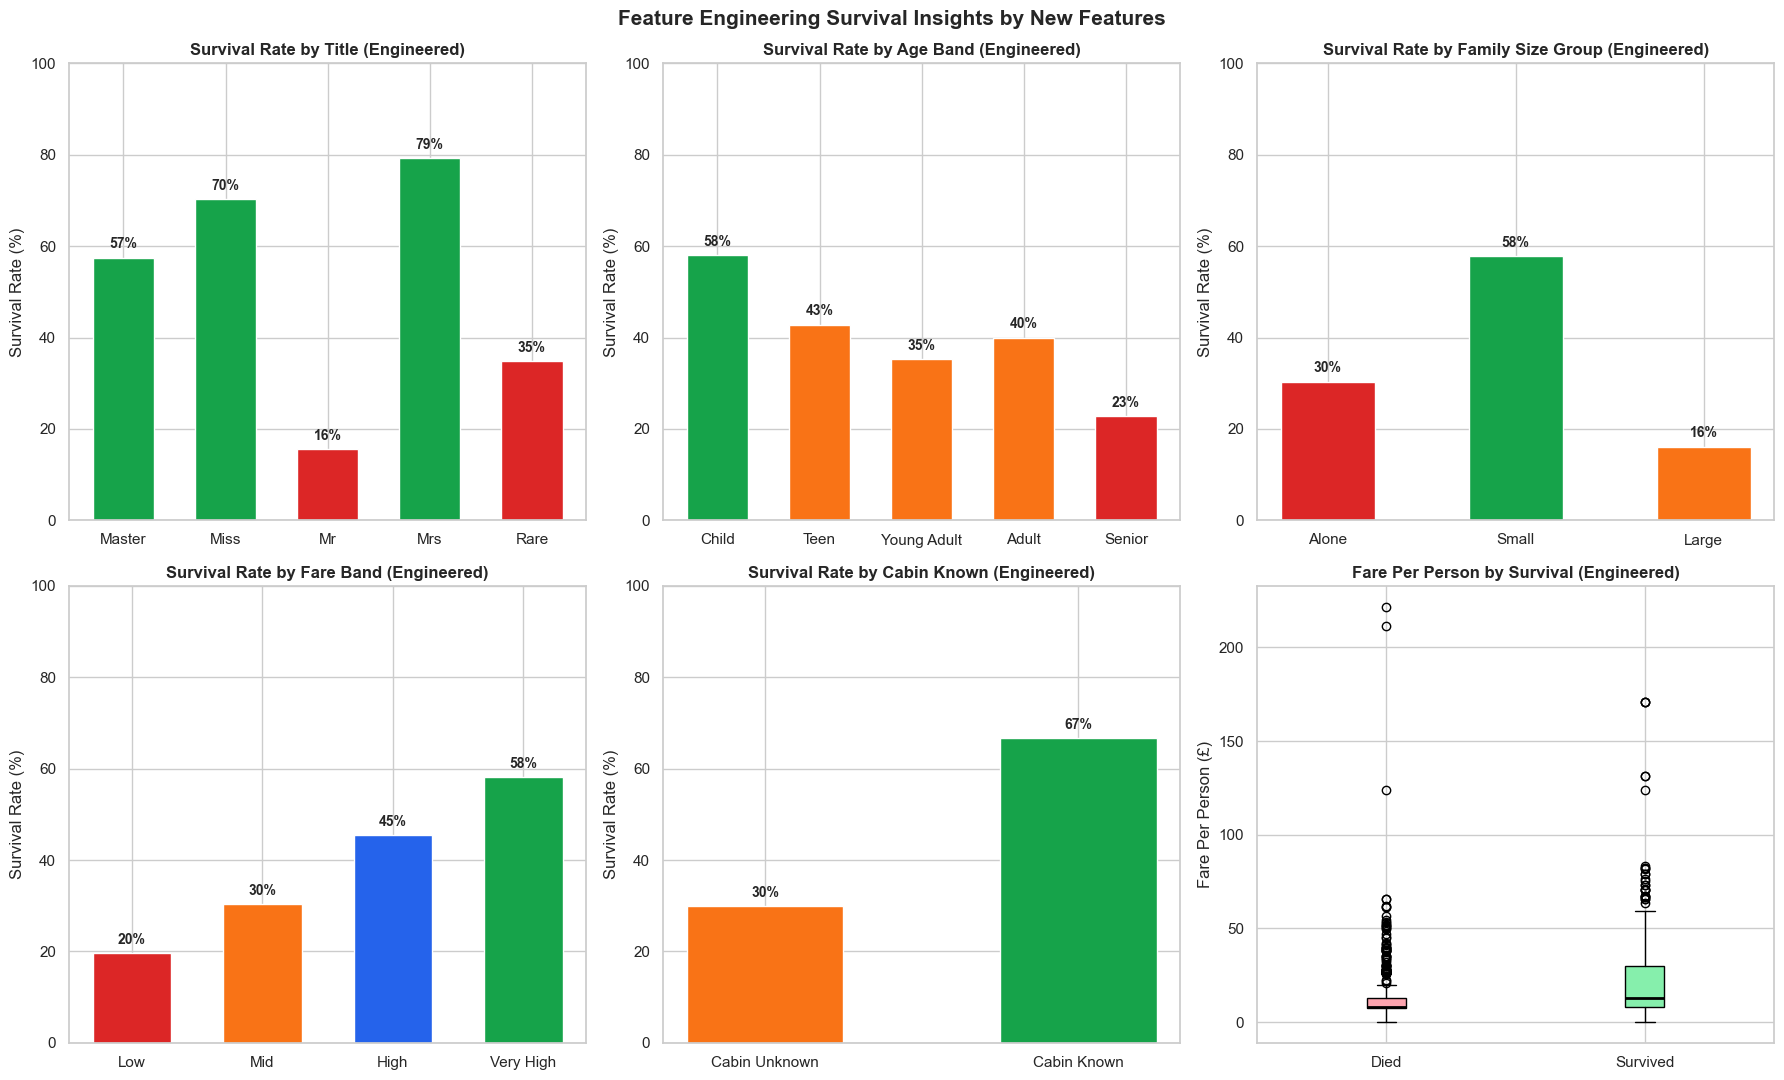

In [56]:
#  Survival Rates by Engineered Features 

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Feature Engineering Survival Insights by New Features',
             fontsize=15, fontweight='bold')

# Panel 1 Title
t_surv = titanic.groupby('Title')['Survived'].mean() * 100
colors_t = [GREEN if v >= 50 else RED for v in t_surv.values]
axes[0,0].bar(t_surv.index, t_surv.values, color=colors_t, edgecolor='white', width=0.6)
axes[0,0].set_title('Survival Rate by Title (Engineered)', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate (%)'); axes[0,0].set_ylim(0, 100)
for bar in axes[0,0].patches:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

# Panel 2 Age Band
ab_surv = titanic.groupby('AgeBand', observed=True)['Survived'].mean() * 100
colors_ab = [GREEN if v >= 50 else ORANGE if v >= 35 else RED for v in ab_surv.values]
axes[0,1].bar(ab_surv.index.astype(str), ab_surv.values, color=colors_ab, edgecolor='white', width=0.6)
axes[0,1].set_title('Survival Rate by Age Band (Engineered)', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate (%)'); axes[0,1].set_ylim(0, 100)
for bar in axes[0,1].patches:
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

# Panel 3 Family Size Group
fg_order = ['Alone', 'Small', 'Large']
fg_surv = titanic.groupby('FamilySizeGroup')['Survived'].mean().reindex(fg_order) * 100
axes[0,2].bar(fg_order, fg_surv.values, color=[RED, GREEN, ORANGE], edgecolor='white', width=0.5)
axes[0,2].set_title('Survival Rate by Family Size Group (Engineered)', fontweight='bold')
axes[0,2].set_ylabel('Survival Rate (%)'); axes[0,2].set_ylim(0, 100)
for bar in axes[0,2].patches:
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

# Panel 4 Fare Band
fb_surv = titanic.groupby('FareBand', observed=True)['Survived'].mean() * 100
axes[1,0].bar(fb_surv.index.astype(str), fb_surv.values,
              color=[RED, ORANGE, BLUE, GREEN], edgecolor='white', width=0.6)
axes[1,0].set_title('Survival Rate by Fare Band (Engineered)', fontweight='bold')
axes[1,0].set_ylabel('Survival Rate (%)'); axes[1,0].set_ylim(0, 100)
for bar in axes[1,0].patches:
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

# Panel 5 Cabin Known
cb_surv = titanic.groupby('CabinKnown')['Survived'].mean() * 100
axes[1,1].bar(['Cabin Unknown', 'Cabin Known'], cb_surv.values,
              color=[ORANGE, GREEN], edgecolor='white', width=0.5)
axes[1,1].set_title('Survival Rate by Cabin Known (Engineered)', fontweight='bold')
axes[1,1].set_ylabel('Survival Rate (%)'); axes[1,1].set_ylim(0, 100)
for bar in axes[1,1].patches:
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f'{bar.get_height():.0f}%', ha='center', fontsize=10, fontweight='bold')

# Panel 6 Fare Per Person boxplot
data_box = [titanic[titanic['Survived']==0]['FarePerPerson'],
            titanic[titanic['Survived']==1]['FarePerPerson']]
bp = axes[1,2].boxplot(data_box, patch_artist=True, labels=['Died', 'Survived'],
                        medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#FDA4AF')
bp['boxes'][1].set_facecolor('#86EFAC')
axes[1,2].set_title('Fare Per Person by Survival (Engineered)', fontweight='bold')
axes[1,2].set_ylabel('Fare Per Person (£)')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_6_Project\features_engineered.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

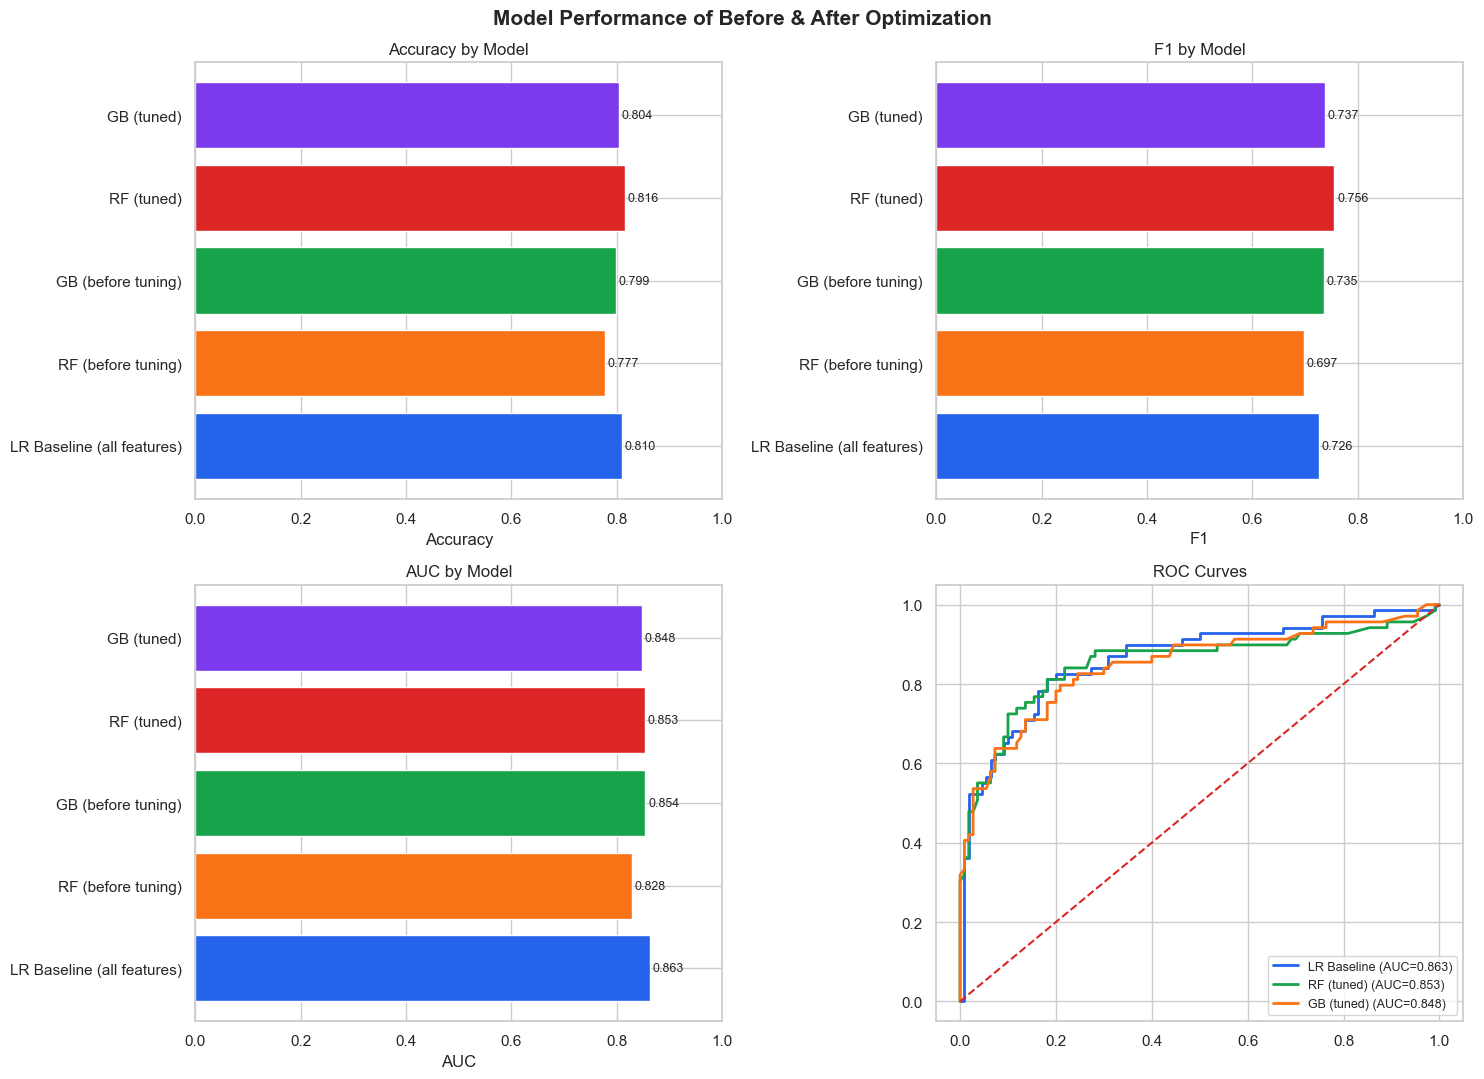

In [62]:
# Model Comparison bar charts 
colors_m = [BLUE, ORANGE, GREEN, RED, PURPLE, TEAL]
model_names = list(results.keys())

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Model Performance of Before & After Optimization', fontsize=15, fontweight='bold')

for i, metric in enumerate(['Accuracy','F1','AUC']):
    ax = axes[i//2, i%2]
    vals = [results[m][metric] for m in model_names]
    bars = ax.barh(model_names, vals, color=colors_m[:len(model_names)], edgecolor='white')
    ax.set_title(f'{metric} by Model')
    ax.set_xlabel(metric); ax.set_xlim(0,1)
    for bar in bars:
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=9)

# ROC curves
ax = axes[1,1]
best_rf = grid_rf.best_estimator_
best_gb = rand_gb.best_estimator_
lr_b = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_all, y_train)
for name, model, X_te, color in [('LR Baseline', lr_b, X_test_all, BLUE),
                                   ('RF (tuned)', best_rf, X_test_sel, GREEN),
                                   ('GB (tuned)', best_gb, X_test_sel, ORANGE)]:
    proba = model.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1], color=RED, linewidth=1.5, linestyle='--')
ax.set_title('ROC Curves'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_6_Project\model_performance.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

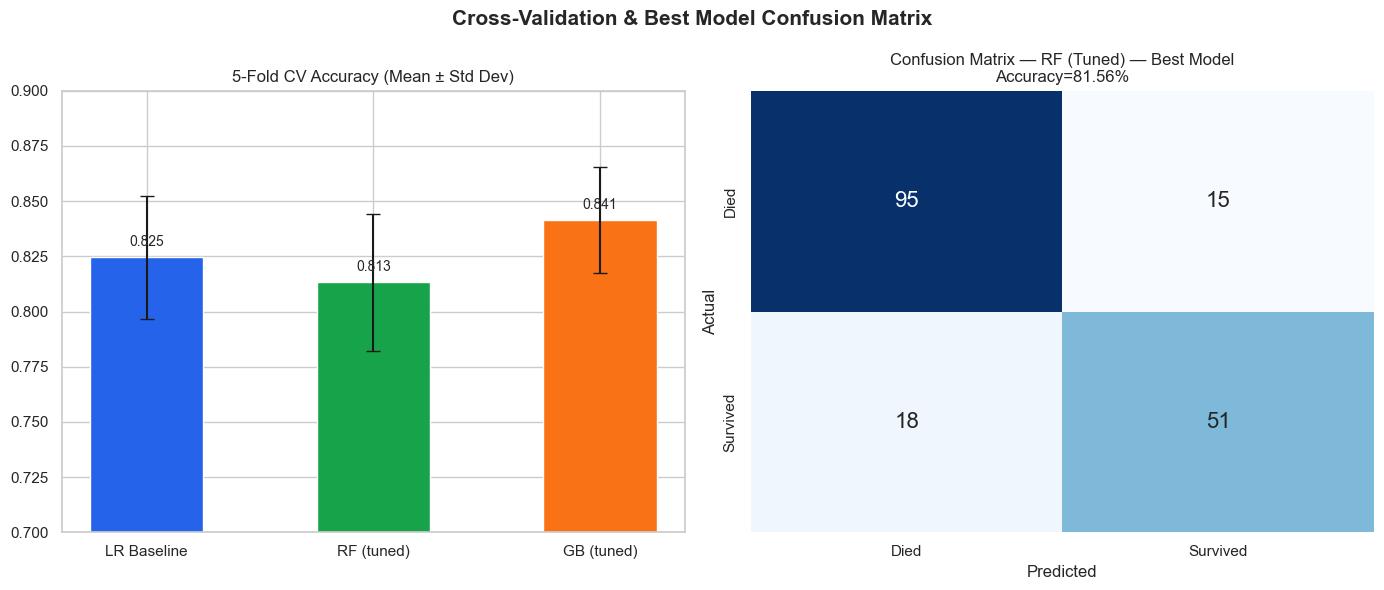

In [52]:
#  Cross-validation and  Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cross-Validation & Best Model Confusion Matrix', fontsize=15, fontweight='bold')

cv_info = [('LR Baseline', lr_b, X_train_all, BLUE),
           ('RF (tuned)', best_rf, X_train_sel, GREEN),
           ('GB (tuned)', best_gb, X_train_sel, ORANGE)]
cv_means, cv_stds, cv_labels = [], [], []
for name, model, X_tr, _ in cv_info:
    scores = cross_val_score(model, X_tr, y_train, cv=StratifiedKFold(5), scoring='accuracy')
    cv_means.append(scores.mean()); cv_stds.append(scores.std()); cv_labels.append(name)

bars = axes[0].bar(cv_labels, cv_means, color=[BLUE,GREEN,ORANGE], edgecolor='white',
                    width=0.5, yerr=cv_stds, capsize=5)
axes[0].set_title('5-Fold CV Accuracy (Mean ± Std Dev)'); axes[0].set_ylim(0.7, 0.9)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=10)

cm = confusion_matrix(y_test, best_rf.predict(X_test_sel))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Died','Survived'], yticklabels=['Died','Survived'], annot_kws={'size':16})
axes[1].set_title(f'Confusion Matrix — RF (Tuned) — Best Model\nAccuracy={accuracy_score(y_test,best_rf.predict(X_test_sel)):.2%}')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_6_Project\confusion_matrix.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

---
## Summary & Conclusions

### Performance Comparison Table

| Model | Accuracy | F1 | AUC |
|-------|----------|----|-----|
| **RF (tuned)** | **81.56%** | **0.7556** | 0.8529 |
| LR Baseline (all features) | 81.01% | 0.7258 | 0.8630 |
| GB (tuned) | 80.45% | 0.7368 | 0.8476 |
| GB (before tuning) | 79.89% | 0.7353 | 0.8540 |
| RF (before tuning) | 77.65% | 0.6970 | 0.8277 |

### Best Model: Random Forest (Tuned)
- **Accuracy 81.56%**  +3.91 points improvement over RF before tuning
- **F1 = 0.7556**  best balance of precision and recall of all models
- **Best params:** n_estimators=300, max_depth=5, min_samples_split=5, max_features='sqrt'

### Key Findings

1. **Feature engineering created 9 new features**  Title, FamilySize, IsAlone, FamilySizeGroup, AgeBand, FarePerPerson, FareBand, CabinKnown, SexPclass  providing richer signal than the original raw columns alone.
2. **The SexPclass interaction term** ranked among the top features by both correlation and RF importance, capturing how sex and class compound together to determine survival probability.
3. **FarePerPerson** outperformed raw Fare after correcting for shared-ticket groups, providing a cleaner signal for individual socioeconomic level.
4. **Tuning improved RF substantially** (+3.91 points accuracy, +5.86 points F1) but improved GB only slightly  highlighting that results depend on the model and dataset, not just the technique.
5. **The Logistic Regression baseline remains competitive** on AUC (0.863), demonstrating that well-engineered features reduce the gap between simple and complex models.